In [2]:

#load data
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
#check structure
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [3]:
#Descriptive Statistics
#Headline Length
# Calculate headline length
df['headline_length'] = df['headline'].apply(len)

# Display descriptive statistics
headline_stats = df['headline_length'].describe()

print(headline_stats)

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


In sentiment/news analysis, headline length can help:

understand writing patterns
compare publishers
identify unusually short/long headlines
support feature engineering for ML models

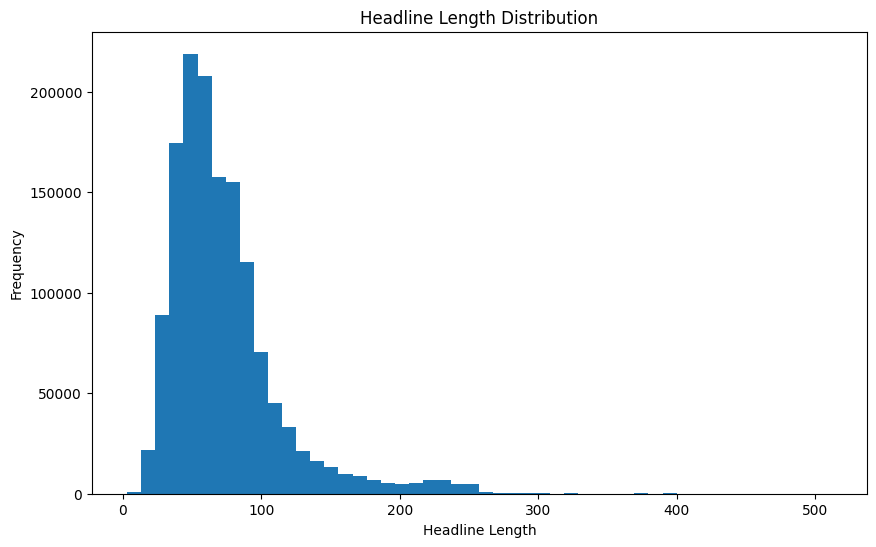

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['headline_length'], bins=50)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

## Insights from the Histogram

1. Most headlines have moderate lengths
   - The majority of headlines fall within a medium-length range.
   - This suggests financial news headlines are generally concise and readable.

2. The distribution is positively skewed
   - The histogram has a long right tail.
   - A small number of headlines are much longer than the majority.

3. Peak frequency occurs around medium lengths
   - Headlines around 50–80 characters appear most frequently.
   - This may reflect common editorial writing practices.

4. Long headlines are relatively rare
   - Frequencies decrease as headline length increases.
   - Headlines above 200 characters are uncommon.

5. Presence of outliers
   - A few extremely long headlines exist in the dataset.
   - These may contain detailed explanations or multiple events.

6. Potential relevance for sentiment analysis
   - Headline length could be used as a feature in machine learning models.
   - Longer headlines may contain richer sentiment-related information.

In [6]:
#Articles per Publisher
publisher_counts = df['publisher'].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

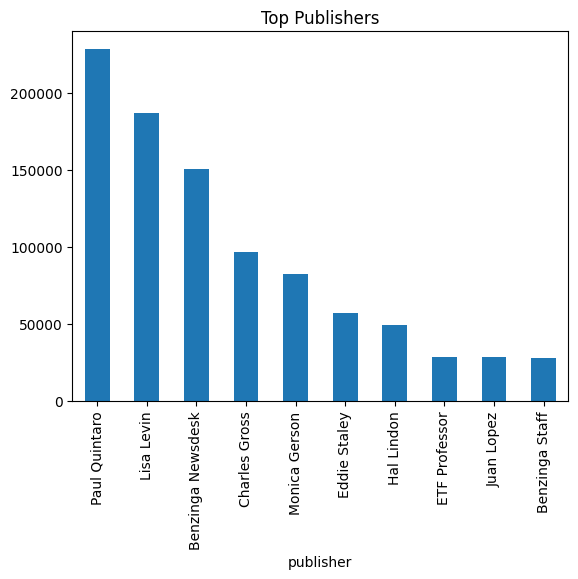

In [7]:
#Top pulisher Plot:
publisher_counts.head(10).plot(kind='bar')
plt.title("Top Publishers")
plt.show()

In [10]:
# Publication Dates

# Convert date column to datetime
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

# Count news articles by publication date
publication_counts = df['date'].dt.date.value_counts().sort_index()

print(publication_counts)

date
2009-02-14      1
2009-04-27      2
2009-04-29      1
2009-05-22      1
2009-05-27      6
             ... 
2020-06-07     25
2020-06-08    765
2020-06-09    803
2020-06-10    807
2020-06-11    544
Name: count, Length: 3955, dtype: int64


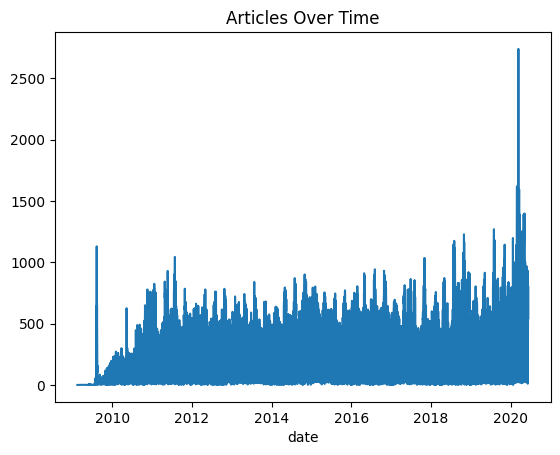

In [11]:
#Time trend:
df.groupby(df['date'].dt.date).size().plot()
plt.title("Articles Over Time")
plt.show()

In [12]:
#Text Analysis
#TF-IDF Keywords
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['headline'])

print(vectorizer.get_feature_names_out())

['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


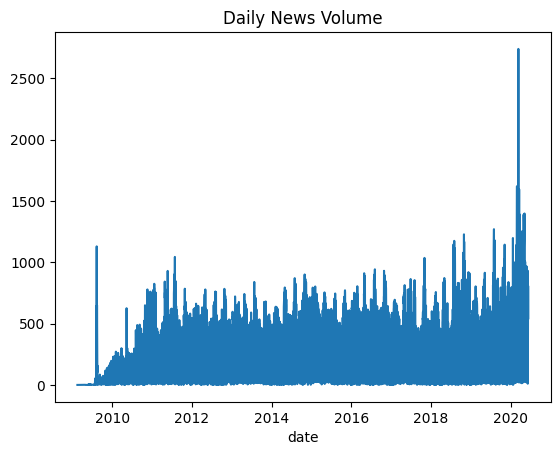

In [13]:
#Simple Topic Modeling (LDA)
daily_counts = df.groupby(df['date'].dt.date).size()

daily_counts.plot()
plt.title("Daily News Volume")
plt.show()

## Insights from Daily News Volume Analysis

1. Overall increase in news volume over time
   - The number of published news articles generally increases from 2009 to 2020.
   - This suggests growing financial news activity and increased market coverage over the years.

2. Presence of significant spikes
   - Several sharp spikes appear throughout the timeline.
   - These spikes may correspond to major financial events, earnings reports, economic crises, or important market announcements.

3. Higher activity in recent years
   - News publication frequency becomes much higher after 2018.
   - This may indicate increased market participation, faster digital news reporting, or broader financial media coverage.

4. Extreme peak around 2020
   - The largest spike occurs near 2020.
   - This could be related to major global financial events or periods of heightened market volatility.

5. Continuous fluctuations
   - Daily news volume changes frequently across time.
   - Financial news activity is highly dynamic and influenced by ongoing economic and market conditions.

6. Potential relationship with stock market behavior
   - High news volume periods may correlate with increased stock market volatility or major market events.
   - This can be useful for sentiment analysis and financial forecasting models.

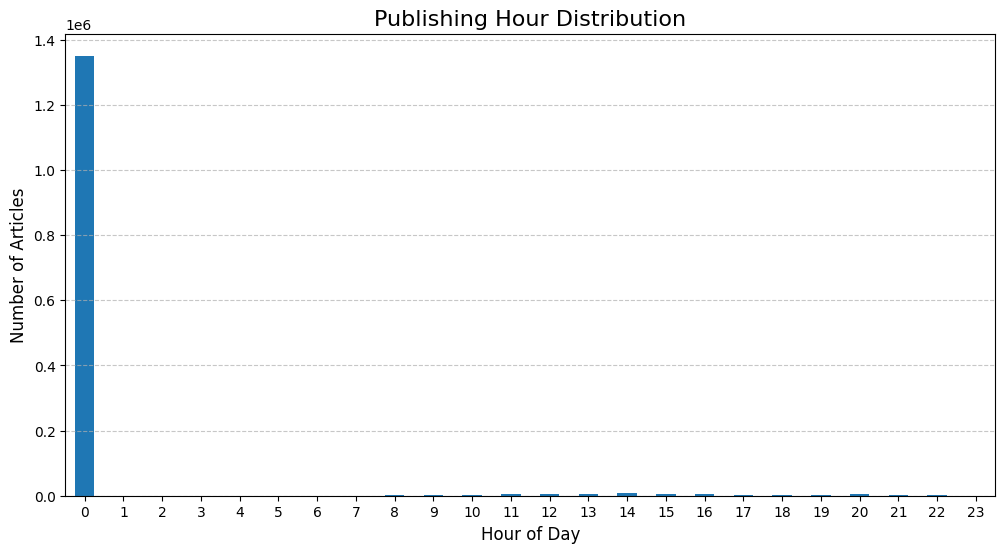

In [15]:
import matplotlib.pyplot as plt

# Extract publishing hour
df['hour'] = df['date'].dt.hour

# Count publications by hour
hour_counts = df['hour'].value_counts().sort_index()

# Create larger figure
plt.figure(figsize=(12,6))

# Create bar plot
hour_counts.plot(kind='bar')

# Add labels and title
plt.title("Publishing Hour Distribution", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Publishing Hour Distribution

### Key Insights
* **Peak Publishing Time**: The data shows an overwhelming concentration of articles published at **00:00 (midnight)**, with over **1.35 million articles**.
* **Off-Peak Hours**: Publishing is extremely quiet between **01:00 and 07:00**.
* **Daytime Distribution**: Articles are published at a relatively consistent, albeit much lower, rate during standard business hours (08:00–22:00).

In [ ]:
#Publisher Analysis Extract Domains (if emails)
df['domain'] = df['publisher'].str.extract(r'@(.+)')

df['domain'].value_counts().head()


domain
benzinga.com      7937
gmail.com          139
andyswan.com         5
investdiva.com       2
tothetick.com        2
Name: count, dtype: int64